# Phase 1 — Exploratory Data Analysis
**AI-Powered Steel Surface Defect Detection**

Severstal steel surface dataset. Goals:
- Answer the four business questions (most common defect, defective %, largest-area defect, production lines).
- Characterise class imbalance, defect size, co-occurrence and image properties.
- Save publication-quality figures to `eda/` for the report & dashboard.


In [1]:
import sys, os
from pathlib import Path

# make the project root importable when running from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from src import config, utils
from src.rle import rle_decode, mask_to_color
from src.dataset import load_annotations, build_image_df

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
config.ensure_dirs()
EDA = config.EDA_DIR
utils.seed_everything()
print("Project root:", ROOT)


Project root: C:\Working\AI ML Projetcs\Steel Plant Manufacturing Fault


## 1. Load data

In [2]:
ann = load_annotations()                 # one row per defect instance
img_df = build_image_df(ann)             # one row per image (incl. defect-free)

print(f"Annotation rows (defect instances): {len(ann):,}")
print(f"Total train images:                 {len(img_df):,}")
print(f"Defect-free images:                 {(img_df.has_defect==0).sum():,}")
print(f"Images with >=1 defect:             {(img_df.has_defect==1).sum():,}")
ann.head()


Annotation rows (defect instances): 7,095
Total train images:                 12,568
Defect-free images:                 5,902
Images with >=1 defect:             6,666


,ImageId,ClassId,EncodedPixels
0,0002cc93b.jpg,1,29102 12 29346 24 29602 24 29858 24 30114 24 3...
1,0007a71bf.jpg,3,18661 28 18863 82 19091 110 19347 110 19603 11...
2,000a4bcdd.jpg,1,37607 3 37858 8 38108 14 38359 20 38610 25 388...
3,000f6bf48.jpg,4,131973 1 132228 4 132483 6 132738 8 132993 11 ...
4,0014fce06.jpg,3,229501 11 229741 33 229981 55 230221 77 230468...


## 2. Business Q1 — Which defect is most common?
We look at it two ways: by **number of images** containing each class, and by
**number of defect instances** (an image can hold several instances of a class).


C:\Users\triaz\AppData\Local\Temp\ipykernel_31580\2741980858.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=inst_counts.index, y=inst_counts.values, ax=axes[1], palette="rocket")


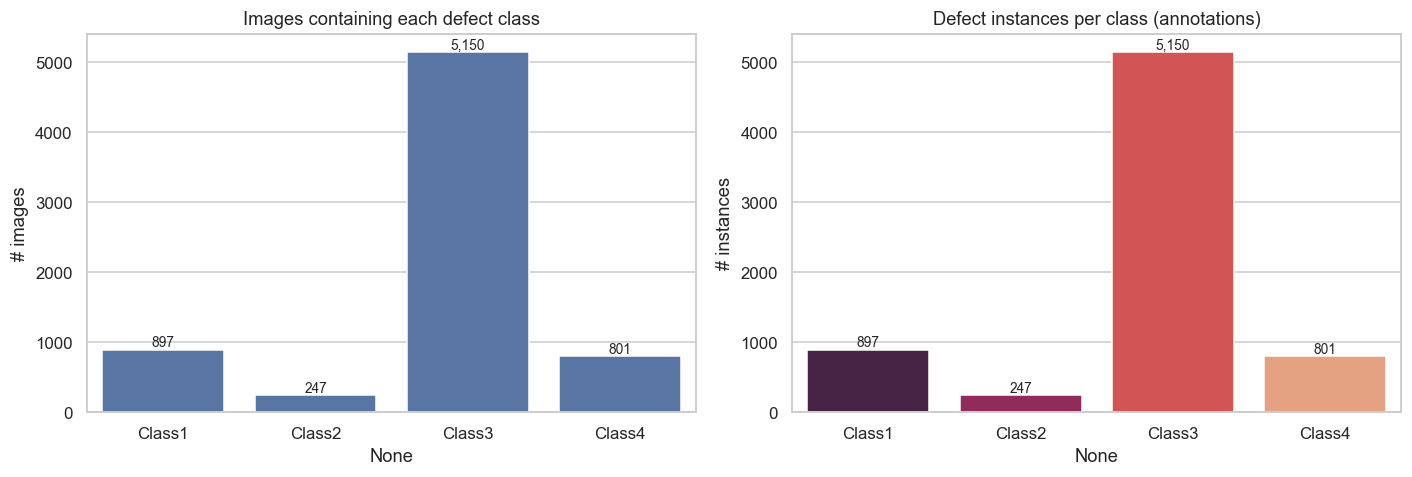

Most common defect (by images): Class3


In [3]:
class_img_counts = img_df[["c1","c2","c3","c4"]].sum()
class_img_counts.index = [config.CLASS_NAMES[c] for c in config.DEFECT_CLASSES]
inst_counts = ann["ClassId"].value_counts().sort_index()
inst_counts.index = [config.CLASS_NAMES[c] for c in inst_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=class_img_counts.index, y=class_img_counts.values, ax=axes[0])
axes[0].set_title("Images containing each defect class")
axes[0].set_ylabel("# images")
for i, v in enumerate(class_img_counts.values):
    axes[0].text(i, v+40, f"{int(v):,}", ha="center", fontsize=9)

sns.barplot(x=inst_counts.index, y=inst_counts.values, ax=axes[1], palette="rocket")
axes[1].set_title("Defect instances per class (annotations)")
axes[1].set_ylabel("# instances")
for i, v in enumerate(inst_counts.values):
    axes[1].text(i, v+40, f"{int(v):,}", ha="center", fontsize=9)

plt.tight_layout(); plt.savefig(EDA/"01_defect_distribution.png", bbox_inches="tight"); plt.show()
print("Most common defect (by images):", class_img_counts.idxmax())


## 3. Business Q3 — What percentage of sheets are defective?
And how many defects co-occur on a single sheet?


C:\Users\triaz\AppData\Local\Temp\ipykernel_31580\3440333464.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ndist.index.astype(str), y=ndist.values, ax=axes[1], palette="viridis")


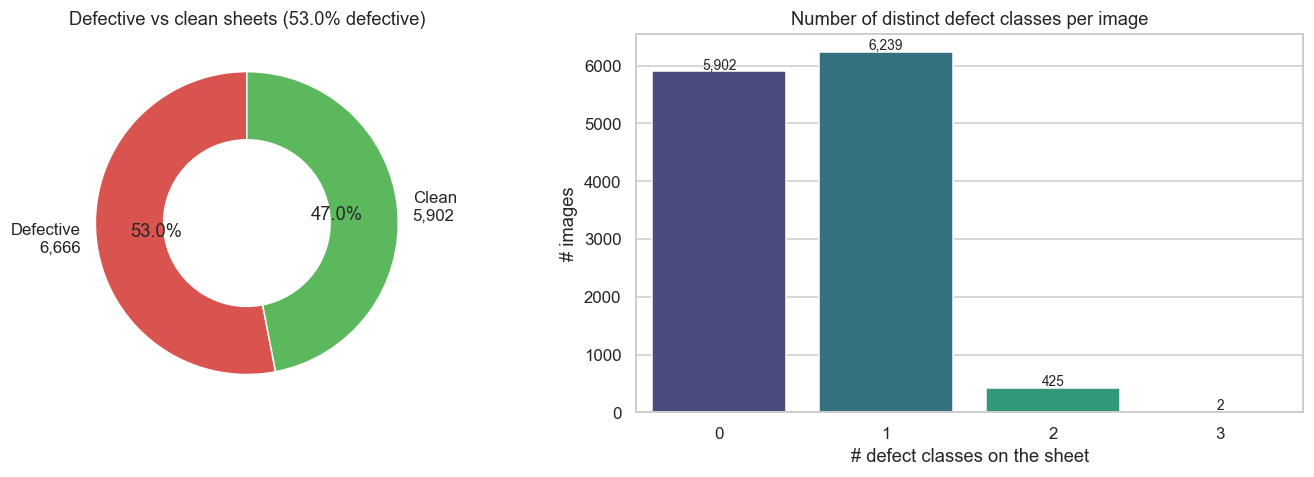

53.0% of sheets are defective.
Multi-defect images: 427


In [4]:
defective = (img_df.has_defect==1).sum()
clean = (img_df.has_defect==0).sum()
pct_def = 100*defective/len(img_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].pie([defective, clean], labels=[f"Defective\n{defective:,}", f"Clean\n{clean:,}"],
            autopct="%1.1f%%", colors=["#d9534f", "#5cb85c"], startangle=90,
            wedgeprops=dict(width=0.45))
axes[0].set_title(f"Defective vs clean sheets ({pct_def:.1f}% defective)")

ndist = img_df["num_defects"].value_counts().sort_index()
sns.barplot(x=ndist.index.astype(str), y=ndist.values, ax=axes[1], palette="viridis")
axes[1].set_title("Number of distinct defect classes per image")
axes[1].set_xlabel("# defect classes on the sheet"); axes[1].set_ylabel("# images")
for i, v in enumerate(ndist.values):
    axes[1].text(i, v+40, f"{int(v):,}", ha="center", fontsize=9)

plt.tight_layout(); plt.savefig(EDA/"02_defective_share.png", bbox_inches="tight"); plt.show()
print(f"{pct_def:.1f}% of sheets are defective.")
print("Multi-defect images:", int((img_df.num_defects>1).sum()))


## 4. Defect area distribution
Defect pixel area is read directly from the RLE (sum of run lengths) — no need to
rasterise the full mask. Area is expressed as a **% of the 1600×256 sheet**.


          count    min     max    mean
size_bin                              
Small      2366  0.028   1.359   0.750
Medium     2364  1.361   4.506   2.625
Large      2365  4.507  89.902  13.512


C:\Users\triaz\AppData\Local\Temp\ipykernel_31580\1409313298.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bin_counts.index, y=bin_counts.values, ax=axes[1], palette="flare")


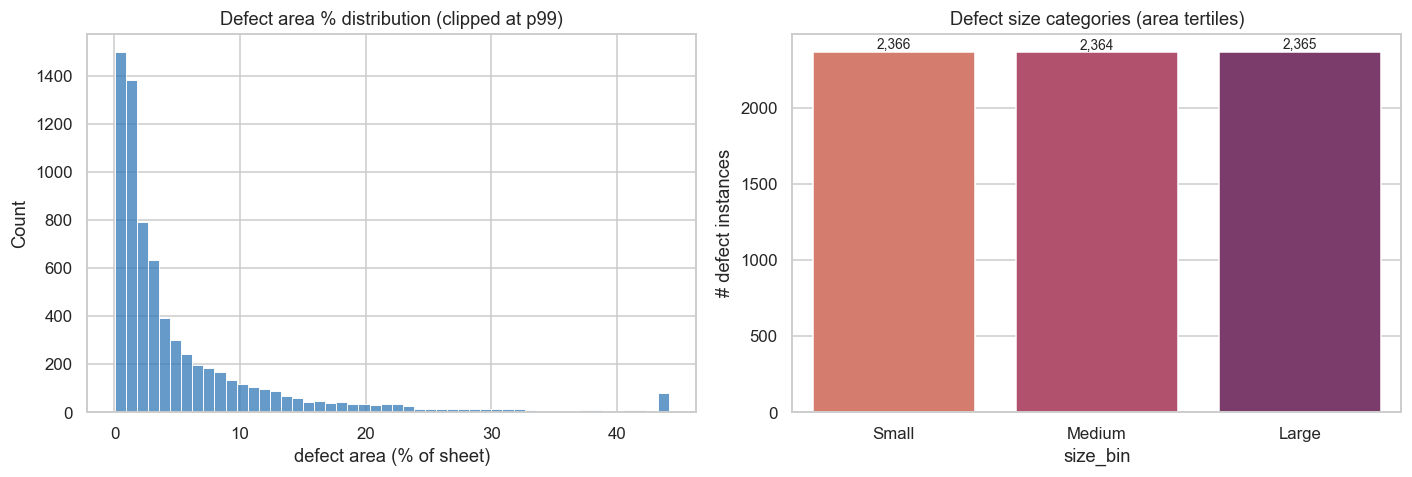

In [5]:
SHEET_PX = config.IMG_HEIGHT * config.IMG_WIDTH

def rle_area(rle):
    if pd.isna(rle):
        return 0
    return int(np.asarray(rle.split(), dtype=int)[1::2].sum())

ann = ann.copy()
ann["area_px"] = ann["EncodedPixels"].map(rle_area)
ann["area_pct"] = 100*ann["area_px"]/SHEET_PX

# tertiles -> Small / Medium / Large
ann["size_bin"] = pd.qcut(ann["area_pct"], q=3, labels=["Small","Medium","Large"])
print(ann.groupby("size_bin")["area_pct"].agg(["count","min","max","mean"]).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(ann["area_pct"].clip(upper=ann.area_pct.quantile(0.99)), bins=50, ax=axes[0], color="#337ab7")
axes[0].set_title("Defect area % distribution (clipped at p99)")
axes[0].set_xlabel("defect area (% of sheet)")

bin_counts = ann["size_bin"].value_counts().reindex(["Small","Medium","Large"])
sns.barplot(x=bin_counts.index, y=bin_counts.values, ax=axes[1], palette="flare")
axes[1].set_title("Defect size categories (area tertiles)")
axes[1].set_ylabel("# defect instances")
for i, v in enumerate(bin_counts.values):
    axes[1].text(i, v+20, f"{int(v):,}", ha="center", fontsize=9)

plt.tight_layout(); plt.savefig(EDA/"03_defect_area_distribution.png", bbox_inches="tight"); plt.show()


## 5. Business Q4 — Which defect causes the largest affected area?
Compare per-class total and mean defect area.


         mean  median        sum  count
Class1  1.065   0.812    955.110    897
Class2  0.825   0.719    203.728    247
Class3  6.225   2.918  32057.348   5150
Class4  8.392   6.191   6722.063    801


C:\Users\triaz\AppData\Local\Temp\ipykernel_31580\1340089881.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=area_by_class.index, y=area_by_class["mean"], ax=axes[0], palette="mako")
C:\Users\triaz\AppData\Local\Temp\ipykernel_31580\1340089881.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ann.assign(cls=ann.ClassId.map(config.CLASS_NAMES)),


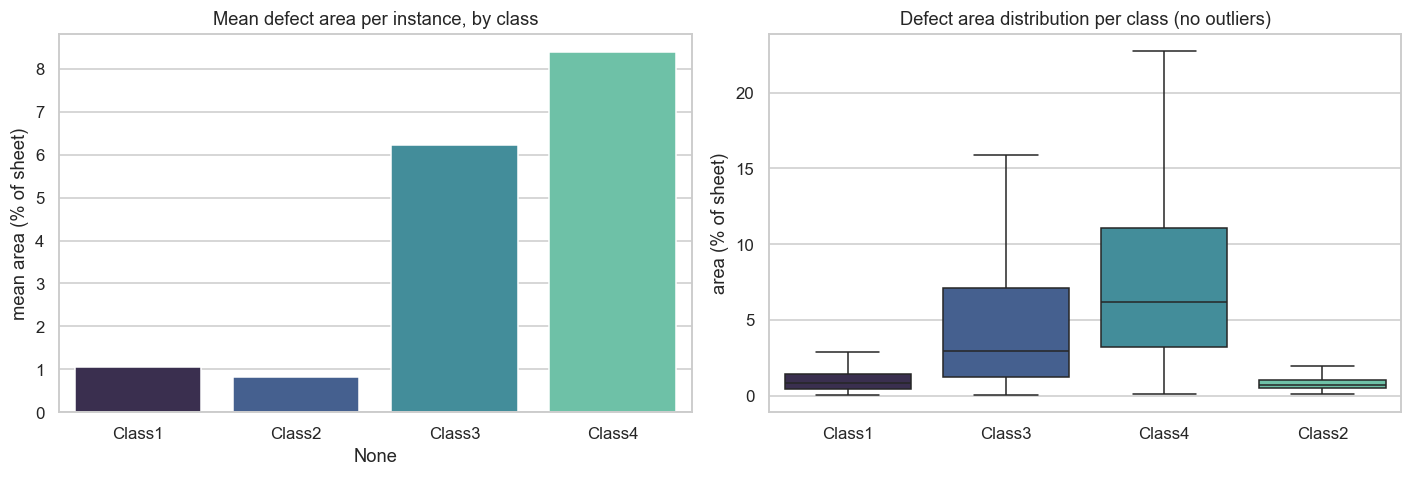

Largest mean affected area: Class4
Largest total affected area: Class3


In [6]:
area_by_class = ann.groupby("ClassId")["area_pct"].agg(["mean","median","sum","count"])
area_by_class.index = [config.CLASS_NAMES[c] for c in area_by_class.index]
print(area_by_class.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=area_by_class.index, y=area_by_class["mean"], ax=axes[0], palette="mako")
axes[0].set_title("Mean defect area per instance, by class"); axes[0].set_ylabel("mean area (% of sheet)")
sns.boxplot(data=ann.assign(cls=ann.ClassId.map(config.CLASS_NAMES)),
            x="cls", y="area_pct", ax=axes[1], showfliers=False, palette="mako")
axes[1].set_title("Defect area distribution per class (no outliers)"); axes[1].set_ylabel("area (% of sheet)")
axes[1].set_xlabel("")
plt.tight_layout(); plt.savefig(EDA/"04_area_by_class.png", bbox_inches="tight"); plt.show()
print("Largest mean affected area:", area_by_class["mean"].idxmax())
print("Largest total affected area:", area_by_class["sum"].idxmax())


## 6. Correlation & co-occurrence analysis
Do defect classes tend to appear together on the same sheet?


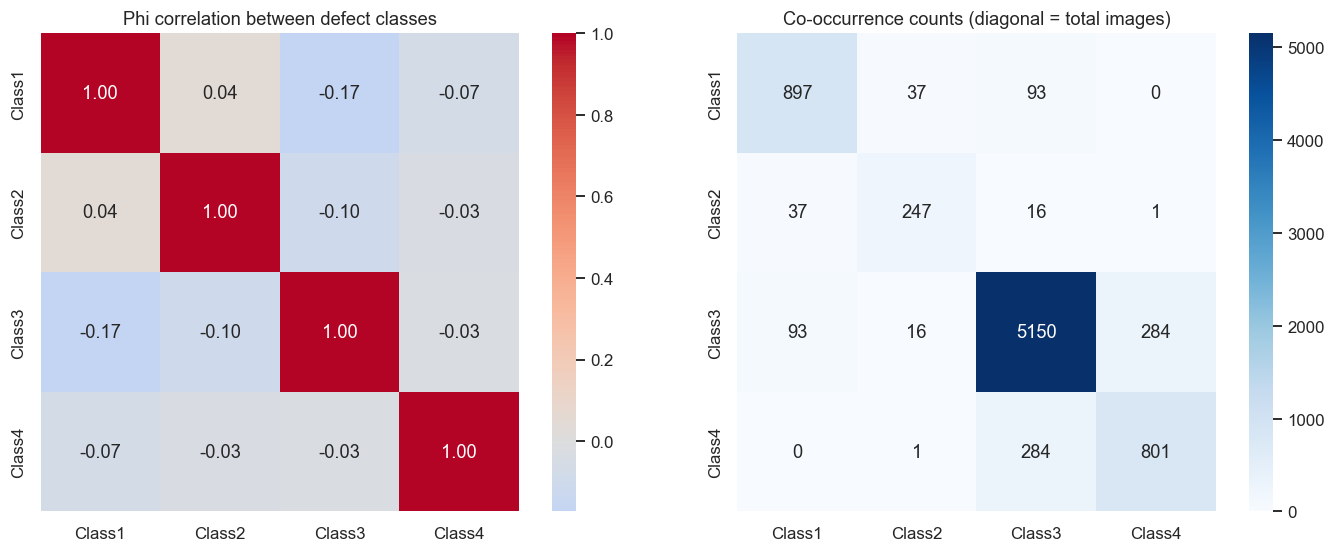

In [7]:
onehot = img_df[["c1","c2","c3","c4"]].rename(
    columns={f"c{c}": config.CLASS_NAMES[c] for c in config.DEFECT_CLASSES})

corr = onehot.corr()
# co-occurrence counts (how many images have both class i and j)
cooc = onehot.T.dot(onehot)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0], square=True)
axes[0].set_title("Phi correlation between defect classes")
sns.heatmap(cooc, annot=True, fmt="d", cmap="Blues", ax=axes[1], square=True)
axes[1].set_title("Co-occurrence counts (diagonal = total images)")
plt.tight_layout(); plt.savefig(EDA/"05_correlation_cooccurrence.png", bbox_inches="tight"); plt.show()


## 7. Image resolution analysis
Severstal images are nominally 1600×256. We verify on a random sample.


In [8]:
rng = np.random.default_rng(config.SEED)
sample_ids = rng.choice(img_df.ImageId.values, size=300, replace=False)
dims = []
for iid in sample_ids:
    im = cv2.imread(str(config.TRAIN_IMG_DIR/iid))
    dims.append(im.shape[:2])  # (H, W)
dims = pd.DataFrame(dims, columns=["H","W"])
print("Unique (H,W) in 300-image sample:")
print(dims.value_counts())
ar = (dims.W/dims.H).round(3)
print("Aspect ratio (W/H):", ar.unique())


Unique (H,W) in 300-image sample:
H    W   
256  1600    300
Name: count, dtype: int64
Aspect ratio (W/H): [6.25]


## 8. Sample defects with mask overlays
One representative image per class with its ground-truth mask overlaid.


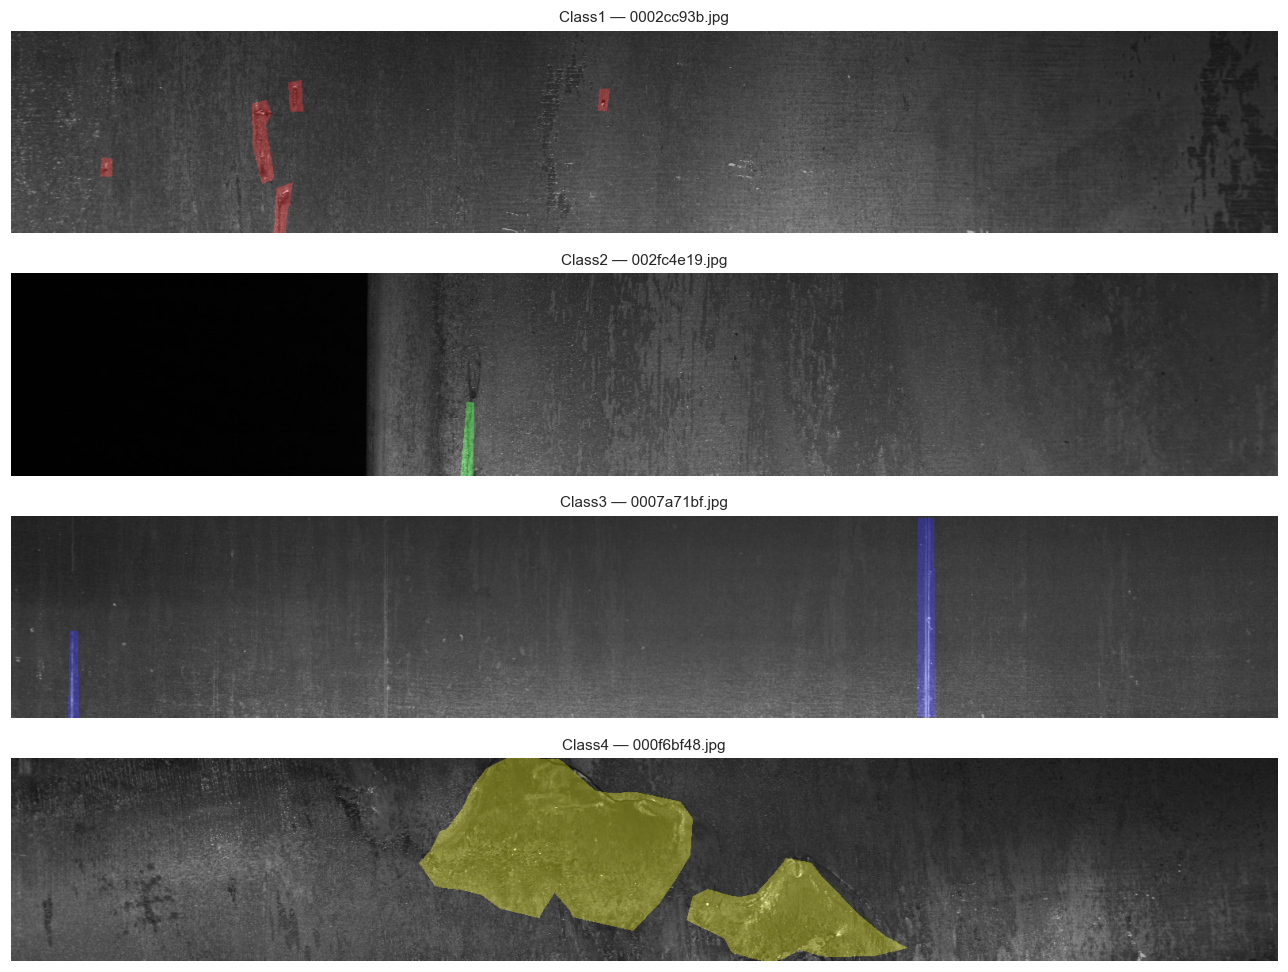

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(14, 9))
for ax, cls in zip(axes, config.DEFECT_CLASSES):
    row = ann[ann.ClassId==cls].iloc[0]
    img = cv2.cvtColor(cv2.imread(str(config.TRAIN_IMG_DIR/row.ImageId)), cv2.COLOR_BGR2RGB)
    mask = rle_decode(row.EncodedPixels)
    color = np.zeros_like(img); color[mask==1] = config.CLASS_COLORS[cls]
    overlay = cv2.addWeighted(img, 0.7, color, 0.3, 0)
    ax.imshow(overlay); ax.set_title(f"{config.CLASS_NAMES[cls]} — {row.ImageId}", fontsize=10)
    ax.axis("off")
plt.tight_layout(); plt.savefig(EDA/"06_sample_overlays.png", bbox_inches="tight"); plt.show()


## 9. Business Q2 — Which production lines have the highest defects?
**Data limitation:** the Severstal dataset ships only `ImageId` (a content hash),
`ClassId` and `EncodedPixels`. There is **no production-line, timestamp, or
coil/batch metadata**, so this question cannot be answered from the data as given.

To support it in production we would join an MES/line-tracking table on image
capture time → line ID. For the dashboard we will treat the inference batch as the
unit of analysis; if the client supplies a line mapping we can group by it directly.


## 10. Export summary stats for the report / dashboard

In [10]:
summary = {
    "total_images": len(img_df),
    "defective_images": int((img_df.has_defect==1).sum()),
    "clean_images": int((img_df.has_defect==0).sum()),
    "pct_defective": round(100*(img_df.has_defect==1).mean(), 2),
    "multi_defect_images": int((img_df.num_defects>1).sum()),
    "defect_instances": len(ann),
    "most_common_defect_by_images": config.CLASS_NAMES[int(img_df[["c1","c2","c3","c4"]].sum().values.argmax())+1],
    "largest_mean_area_class": area_by_class["mean"].idxmax(),
    "largest_total_area_class": area_by_class["sum"].idxmax(),
}
for c in config.DEFECT_CLASSES:
    summary[f"images_{config.CLASS_NAMES[c]}"] = int(img_df[f"c{c}"].sum())

summary_df = pd.DataFrame([summary]).T.rename(columns={0:"value"})
out = config.REPORTS_DIR/"eda_summary.csv"
summary_df.to_csv(out)
print("Saved", out)
summary_df


Saved C:\Working\AI ML Projetcs\Steel Plant Manufacturing Fault\reports\eda_summary.csv


,value
total_images,12568
defective_images,6666
clean_images,5902
pct_defective,53.04
multi_defect_images,427
defect_instances,7095
most_common_defect_by_images,Class3
largest_mean_area_class,Class4
largest_total_area_class,Class3
images_Class1,897


## Key findings

- **~53% of sheets are defective**; the rest are clean (a strong, usable signal but
  also a balanced-enough binary target).
- **Class 3 dominates** by a wide margin (~5,000 images) while **Class 2 is rare**
  (~210 images) — a ~24× imbalance that classification & segmentation must handle
  with class weighting / stratified splits / augmentation.
- **427 images carry multiple defect classes** → true multi-label classification is
  the more faithful framing than single-label.
- Defect **areas are heavily right-skewed**: most defects are small, a long tail is
  large. This motivates the area-based severity score in Phase 7.
- **All images are 1600×256** — no resolution cleaning needed; we can resize/crop
  uniformly for training.
- **Production-line analysis is not possible** from the provided columns (no line
  metadata); flagged for the dashboard phase.

Next → **Phase 2: image enhancement (CLAHE)**.
